# Демовариант 1

## Задание 1

В физике моделируют падение тела: начальная скорость $v_0 = 0$, ускорение $g = 9.8$ м/с², шаг времени $\Delta t = 10^{-4}$ с, количество шагов $N = 10^5$. Вычислите положение тела через $t = N \cdot \Delta t$ двумя способами:
- обычное суммирование,
- суммирование по Кахану.

Сравните результаты с аналитической формулой $s = \frac{1}{2} g t^2$.

*Что такое ошибка округления в арифметике с плавающей точкой и как алгоритм Кахана помогает её уменьшить?*

In [2]:
#Кахан лучше
import numpy as np

# Обычное суммирование
def naive_summation(values):
    s = np.float32(0.0)
    for x in values:
        s += x
    return s

# Суммирование по алгоритму Кахана
def kahan_summation(values):
    s = np.float32(0.0)
    c = np.float32(0.0) # сумма погрешностей
    for x in values:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

In [3]:
g = np.float32(9.8)
dt = np.float32(1e-4)
N = 10**5
t = N * dt

increments = []
for n in range(1, N + 1):
    t_n = n * dt
    t_prev = (n - 1) * dt
    ds = 0.5 * g * (t_n**2 - t_prev**2)
    increments.append(np.float32(ds))

# Аналитическое решение
s_analytical = 0.5 * 9.8 * t**2

s_naive = naive_summation(increments)
s_kahan = kahan_summation(increments)

print(f"Аналитическое решение: {s_analytical}")
print(f"Обычное суммирование: {s_naive}")
print(f"Суммирование Кэхана: {s_kahan}")

Аналитическое решение: 490.0
Обычное суммирование: 489.9978942871094
Суммирование Кэхана: 490.0


In [4]:
#Кахан хуже
import numpy as np

def naive_summation(values):
    s = np.float32(0.0)
    for x in values:
        s += x
    return s

def kahan_summation(values):
    s = np.float32(0.0)
    c = np.float32(0.0)
    for x in values:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

g = np.float32(9.8)
dt = np.float32(1e-4)
N = 10**5
t_total = N * dt

v = np.float32(0.0)
increments = []

for _ in range(N):
    v = v + g * dt
    increments.append(v * dt)

# Аналитическая формула
s_analytical = 0.5 * 9.8 * t_total**2

s_naive = naive_summation(increments)
s_kahan = kahan_summation(increments)

print(f"Обычное суммирование: {s_naive:.10f}")
print(f"Суммирование Кэхана:  {s_kahan:.10f}")
print(f"Аналитическая формула: {s_analytical:.10f}")

Обычное суммирование: 489.9291381836
Суммирование Кэхана:  489.9285583496
Аналитическая формула: 490.0000000000


**Ошибка округления**
Потеря точности при сложении чисел разного порядка из-за ограниченной разрядности компьютера.

**Как алгоритм Кахана помогает?**
Алгоритм Кахана сохраняет "потерянную" часть в отдельной переменной-компенсаторе и добавляет её.

## Задание 2

В химии находят концентрацию вещества из уравнения:
$$f(c) = e^{-c} - 0.5 = 0$$
на интервале $[0, 2]$ методом Ньютона с точностью $10^{-6}$.

*В чём преимущества метода Ньютона перед методом бисекции? Какие у него недостатки?*

In [5]:
import numpy as np

def newton(f, df, x0, tol=1e-6, max_iter=50):
    history = []
    x = x0

    for i in range(max_iter):
        fx = f(x)
        history.append((i+1, x, fx))

        if abs(fx) < tol:
            break

        x = x - fx / df(x)

    return history

# Определяем уравнение
def f(c):
    return np.exp(-c) - 0.5

def df(c):
    return -np.exp(-c)

# Параметры
a, b = 0, 2
x0 = 1  # начальное приближение
tol = 1e-6

# Поиск корня
history = newton(f, df, x0, tol)

# Вывод результатов
print(f"{'Итерация':<10} {'c (концентрация)':<20} {'f(c)':<20}")
print("-" * 50)

for iteration, x_val, fx in history:
    print(f"{iteration:<10} {x_val:<20.10f} {fx:<20.2e}")

# Корень
c_root = history[-1][1]
print(f"Найденная концентрация: c = {c_root:.10f}")
print(f"Значение функции: f(c) = {f(c_root):.2e}")
print(f"Проверка: e^(-c) = {np.exp(-c_root):.10f}")

Итерация   c (концентрация)     f(c)                
--------------------------------------------------
1          1.0000000000         -1.32e-01           
2          0.6408590858         2.68e-02            
3          0.6918036762         6.72e-04            
4          0.6931462785         4.51e-07            
Найденная концентрация: c = 0.6931462785
Значение функции: f(c) = 4.51e-07
Проверка: e^(-c) = 0.5000004510


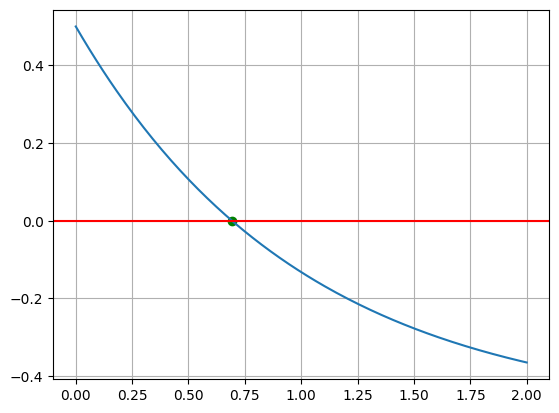

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(c):
    return np.exp(-c) - 0.5

c = np.linspace(0, 2, 200)
y = f(c)

plt.plot(c, y)
plt.axhline(y=0, color='r')
plt.scatter(c_root, 0, color='g')
plt.grid()
plt.show()

**Преимущества метода Ньютона**

* Быстрая сходимость — квадратичная
* Мало итераций — обычно 5-10 вместо 30-50 у бисекции
* Высокая точность — быстро достигает машинной точности

**Недостатки метода Ньютона**
    
* Требуется производная — не всегда известна или сложна в вычислении
* Начальное приближение — должно быть близко к корню, иначе может расходиться
* Может не сойтись — если производная равна нулю или есть точки перегиба
* Не гарантирует сходимость — в отличие от бисекции, которая всегда сходится

## Задание 3

В геометрии находят пересечение окружности $x^2 + y^2 = 9$ и прямой $y = x + 1$ методом Гаусса–Зейделя с точностью $10^{-3}$.

*Как работает метод Гаусса–Зейделя? Чем он отличается от метода функциональных итераций?*

**max 4 балла**

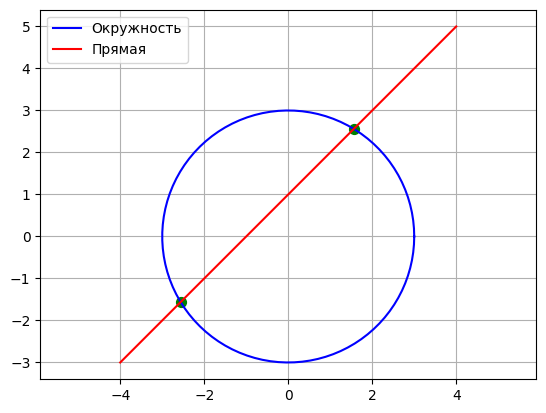

Точка пересечения 1: x = 1.561553, y = 2.561553
Точка пересечения 2: x = -2.561553, y = -1.561553


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Окружность
t = np.linspace(0, 2*np.pi, 100)
x_circ = 3 * np.cos(t)
y_circ = 3 * np.sin(t)

# Прямая
x_line = np.linspace(-4, 4, 100)
y_line = x_line + 1

# Точки пересечения
x1 = (-1 + np.sqrt(17)) / 2
y1 = x1 + 1
x2 = (-1 - np.sqrt(17)) / 2
y2 = x2 + 1

plt.plot(x_circ, y_circ, 'b', label='Окружность')
plt.plot(x_line, y_line, 'r', label='Прямая')
plt.scatter([x1, x2], [y1, y2], color='g', s=50)
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()

print(f"Точка пересечения 1: x = {x1:.6f}, y = {y1:.6f}")
print(f"Точка пересечения 2: x = {x2:.6f}, y = {y2:.6f}")

In [8]:
import math

eps = 1e-3

# === Точка 1 (y > 0) ===
print("=== Точка 1 ===")
x, y = 1.0, 2.0
step = 1
while True:
    x_new = y - 1
    y_new = math.sqrt(9 - x_new**2)  # ← используем НОВЫЙ x сразу!
    print(f"Шаг {step}: x = {x_new:.4f}, y = {y_new:.4f}")

    if abs(x_new - x) + abs(y_new - y) < eps:
        x, y = x_new, y_new
        break
    x, y = x_new, y_new
    step += 1
print(f"({x:.6f}, {y:.6f})\n")

# === Точка 2 (y < 0) ===
print("=== Точка 2 ===")
x, y = -2.0, -1.0
step = 1
while True:
    y_new = x + 1
    x_new = -math.sqrt(9 - y_new**2) # ← порядок изменён для устойчивости
    print(f"Шаг {step}: y = {y_new:.4f}, x = {x_new:.4f}")

    if abs(x_new - x) + abs(y_new - y) < eps:
        x, y = x_new, y_new
        break
    x, y = x_new, y_new
    step += 1
print(f"({x:.6f}, {y:.6f})")

=== Точка 1 ===
Шаг 1: x = 1.0000, y = 2.8284
Шаг 2: x = 1.8284, y = 2.3784
Шаг 3: x = 1.3784, y = 2.6646
Шаг 4: x = 1.6646, y = 2.4958
Шаг 5: x = 1.4958, y = 2.6005
Шаг 6: x = 1.6005, y = 2.5374
Шаг 7: x = 1.5374, y = 2.5761
Шаг 8: x = 1.5761, y = 2.5526
Шаг 9: x = 1.5526, y = 2.5670
Шаг 10: x = 1.5670, y = 2.5582
Шаг 11: x = 1.5582, y = 2.5636
Шаг 12: x = 1.5636, y = 2.5603
Шаг 13: x = 1.5603, y = 2.5623
Шаг 14: x = 1.5623, y = 2.5611
Шаг 15: x = 1.5611, y = 2.5618
Шаг 16: x = 1.5618, y = 2.5614
Шаг 17: x = 1.5614, y = 2.5617
(1.561383, 2.561656)

=== Точка 2 ===
Шаг 1: y = -1.0000, x = -2.8284
Шаг 2: y = -1.8284, x = -2.3784
Шаг 3: y = -1.3784, x = -2.6646
Шаг 4: y = -1.6646, x = -2.4958
Шаг 5: y = -1.4958, x = -2.6005
Шаг 6: y = -1.6005, x = -2.5374
Шаг 7: y = -1.5374, x = -2.5761
Шаг 8: y = -1.5761, x = -2.5526
Шаг 9: y = -1.5526, x = -2.5670
Шаг 10: y = -1.5670, x = -2.5582
Шаг 11: y = -1.5582, x = -2.5636
Шаг 12: y = -1.5636, x = -2.5603
Шаг 13: y = -1.5603, x = -2.5623
Шаг 14: 

**Метод Гаусса-Зейделя** — это способ решения систем уравнений, где каждое новое найденное значение сразу используется для нахождения следующих.

**Метод функциональных итераций (Якоби)** — сначала вычисляются все новые значения из старых, и только потом они обновляются.

**Отличие:** Гаусс-Зейдель использует свежеполученные значения сразу, поэтому он сходится быстрее. Якоби ждёт завершения шага и обновляет все переменные одновременно.

# Демовариант 2

## Задание 1

В экономике считают сумму малых платежей: $N = 10^6$ платежей по $0.0001$ руб.  
Реализуйте два способа вычисления суммы:
- обычное суммирование,
- суммирование по Кахану.

Сравните с теоретической суммой $100$.

*Что такое потеря точности при работе с числами с плавающей точкой? Как её можно минимизировать?*

**max 3 балла**


In [9]:
N = 10**6
t = 0.0001
teor_sum = 100

def simple_sum(arr):
  total = 0.0
  for x in arr:
    total +=x
  return total

def kahan_sum(arr):
    total = 0.0
    compensation = 0.0
    for x in arr:
      y = x - compensation
      t = total + y
      compensation = (t - total) - y
      total = t
    return total

payment = [t] * N
ans_1 = simple_sum(payment)
ans_2 = kahan_sum(payment)
print(ans_1, ans_2)

100.00000000219612 100.0


Потеря точности — это явление, когда результат арифметической операции с числами с плавающей точкой отличается от теоретически правильного математического результата из-за ограниченной разрядности представления чисел в памяти компьютера.

Как минимизировать:

1. использовать суммирование по Кахану
2. суммировать числа в порядке возрастания модуля
3. избегать вычитания близких чисел



## Задание 2

В физике находят корень уравнения:
$$f(x) = \cos(x) - x = 0$$
методом хорд на интервале $[0, 1]$ с точностью $10^{-6}$.

*Опишите метод хорд и его отличие от метода Ньютона.*

**max 3 балла**


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f(x):
  return math.cos(x) - x

def sec_method(a,b, tol = 1e-6, max_iter=100):
  if f(a) * f(b) >= 0 :
    raise ValueError('Функция должна иметь разные знаки на концах отрезка')

  for i in range(max_iter):
    x_next = a - f(a) *(b-a)/(f(b)-f(a))

    if abs(f(x_next)) < tol or (b-a)<tol:
      return x_next, i+1

    if f(a) * f(x_next) < 0:
      b = x_next
    else:
      a = x_next

  print(f"Предупреждение: метод не сошёлся за {max_iter} итераций")
  return x_next, max_iter

a, b = 0.0, 1.0
root, iter = sec_method(a, b)
print (f"Корень: {root:.10f}")
print(f"Значение функции в корне: f({root:.10f}) = {f(root):.2e}")
print(f"Количество итераций: {iter}")


Корень: 0.7390847824
Значение функции в корне: f(0.7390847824) = 5.87e-07
Количество итераций: 5


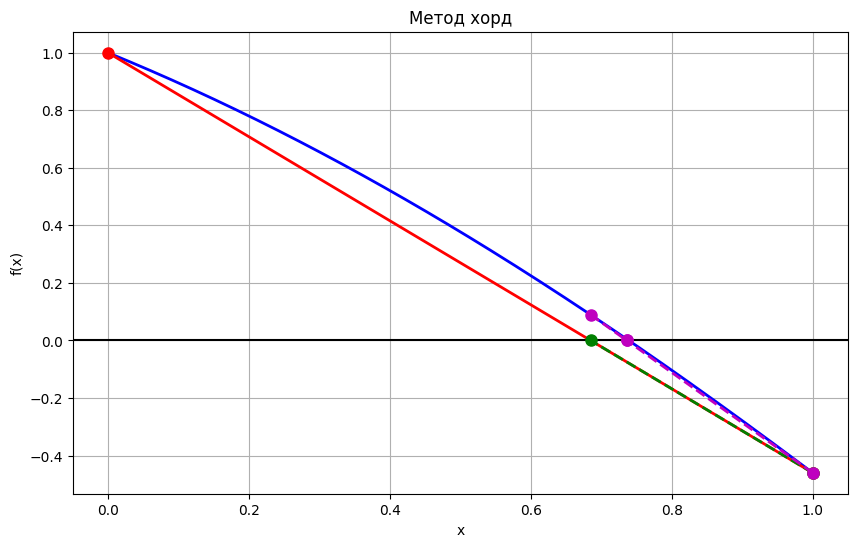

x2 = 0.685073
x3 = 0.736299


In [11]:
def sec_plot(f,x0, x1):
  x_plot = np.linspace(0, 1, 200)
  y_plot = [f(x) for x in x_plot]

  plt.figure(figsize = (10, 6))
  plt.plot(x_plot, y_plot, 'b-', linewidth=2)
  plt.axhline(y= 0, color='black')
  plt.grid(True)

   # Первая итерация
  x2 = a - f(a) * (b - a) / (f(b) - f(a))
  plt.plot([a, b], [f(a), f(b)], 'r-o', linewidth=2, markersize=8)
  plt.plot([b, x2], [f(b), 0], 'g--o', linewidth=2, markersize=8)

  # Вторая итерация
  if f(a) * f(x2) < 0:
      x3 = a - f(a) * (x2 - a) / (f(x2) - f(a))
  else:
      x3 = x2 - f(x2) * (b - x2) / (f(b) - f(x2))

  plt.plot([x2, x3], [f(x2), 0], 'm--o', linewidth=2, markersize=8)
  plt.plot([x1, x3], [f(x1), 0], 'm--o', linewidth=2, markersize=8)

  plt.title('Метод хорд')
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.show()

  return x2, x3

x2, x3 = sec_plot(f, 0.0, 1.0)
print(f"x2 = {x2:.6f}")
print(f"x3 = {x3:.6f}")

## Задание 3

В анализе данных заданы точки: $(1, 2)$, $(2, 3)$, $(3, 5)$.  
Найдите значение в точке $x = 2.5$ с помощью кубической сплайн-интерполяции.

*Что такое сплайн-интерполяция и её преимущества перед полиномиальной интерполяцией?*

**max 4 балла**

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def cubic_spline(x, y):

  n = len(x) - 1 #число сплайнов

  A = np.zeros((4*n, 4*n))
  b = np.zeros(4*n)

  row = 0
  for i in range(n):
    A[row, 4*i:4*(i+1)] = [x[i]**3, x[i]**2, x[i], 1]
    b[row] = y[i]
    row += 1

    A[row, 4*i:4*(i+1)] = [x[i+1]**3, x[i+1]**2, x[i+1], 1]
    b[row] = y[i+1]
    row += 1

  for i in range(n-1):
    A[row, 4*i:4*(i+1)] = [3*x[i+1]**2, 2*x[i+1], 1, 0]
    A[row, 4*(i+1):4*(i+2)] = [-3*x[i+1]**2, -2*x[i+1], -1, 0]
    b[row] = 0
    row += 1

    A[row, 4*i:4*(i+1)] = [6*x[i+1], 2, 0, 0]
    A[row, 4*(i+1):4*(i+2)] = [-6*x[i+1], -2, 0, 0]
    b[row] = 0
    row += 1

  A[row, :4] = [6*x[0], 2, 0, 0]
  b[row] = 0
  row += 1

  A[row, -4:] = [6*x[-1], 2, 0, 0]
  b[row] = 0
  row += 1

  #матричное уравнение A*coeff=b
  coeff = np.linalg.solve(A, b)

  return A, b, coeff

In [13]:
x = [1,2,3]
y = [2,3,5]
cubic_spline(x, y)

(array([[  1.,   1.,   1.,   1.,   0.,   0.,   0.,   0.],
        [  8.,   4.,   2.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   8.,   4.,   2.,   1.],
        [  0.,   0.,   0.,   0.,  27.,   9.,   3.,   1.],
        [ 12.,   4.,   1.,   0., -12.,  -4.,  -1.,   0.],
        [ 12.,   2.,   0.,   0., -12.,  -2.,   0.,   0.],
        [  6.,   2.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  18.,   2.,   0.,   0.]]),
 array([2., 3., 3., 5., 0., 0., 0., 0.]),
 array([ 0.25, -0.75,  1.5 ,  1.  , -0.25,  2.25, -4.5 ,  5.  ]))

In [14]:
x = 2.5
-0.25*x**3 + 2.25*x**2 -4.5*x + 5

3.90625

# Демовариант 3


## Задание 1

В биологии моделируют рост популяции: начальный размер $1$, каждый из $10^6$ шагов добавляет $0.00001$.  
Теоретическая сумма приращений $10$.  
Вычислите итоговую сумму двумя способами:
- прямое сложение,
- с использованием алгоритма Кахана.

*Как суммирование по Кахану улучшает точность?*

**max 3 балла**

---

In [15]:
import numpy as np
from numba import jit

n = 10 ** 6
t = 0.00001
init = 1.0
teor_sum = 10.0


def naive_sum(n, t):
    s = np.float32(0.0)
    for _ in range(n):
        s += t
    return s


@jit(nopython=True)
def kahan_sum(n, t):
    s = np.float32(0.0)
    c = np.float32(0.0)
    for _ in range(n):
        y = t - c
        tmp = s + y
        c = (tmp - s) - y
        s = tmp
    return s


naive_total = init + naive_sum(n, t)
kahan_total = init + kahan_sum(n, t)

print(naive_total, kahan_total)

10.917345 11.0


**Ответ:** Алгоритм Кахана позволяет уменьшить ошибку округления до $2 \varepsilon + \mathcal{O}(n \varepsilon^2)$ где $\varepsilon$ — машинная точность.

Идея: хранить отдельную переменную c, которая «запоминает» младшие биты, потерянные при округлении.


## Задание 2

В экономике ищут равновесную цену:
$$100 - 2P = 50 + 3P$$
методом функциональной итерации с начальным $P_0 = 10$ и точностью $10^{-3}$.

*Опишите метод функциональной итерации и условия его сходимости.*

**max 3 балла**

---


***Решение:*** Для решения данной задачи с помощью метода функциональной иетрации (метод простых итераций). Нам нужно преобразовать $f(P) = 100-2P - 50 - 3P = 0$ к функции вида $P = φ(P) = \frac{50-2P}{3}$

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def simple_iteration(phi, x0, tol=1e-6, max_iter=100):

    x = x0
    iterations = [x]

    for i in range(max_iter):
        x_new = phi(x)
        iterations.append(x_new)

        if abs(x_new - x) < tol:
            print(f"Сходимость достигнута за {i+1} итераций")
            return x_new, iterations

        x = x_new

    print("Достигнуто максимальное число итераций")
    return x, iterations

In [18]:
phi = lambda x: (50-2*x)/3
x0 = 0.5

root, iterations = simple_iteration(phi, x0)

print(f"Найденный корень: {root}")

Сходимость достигнута за 42 итераций
Найденный корень: 9.99999961815182


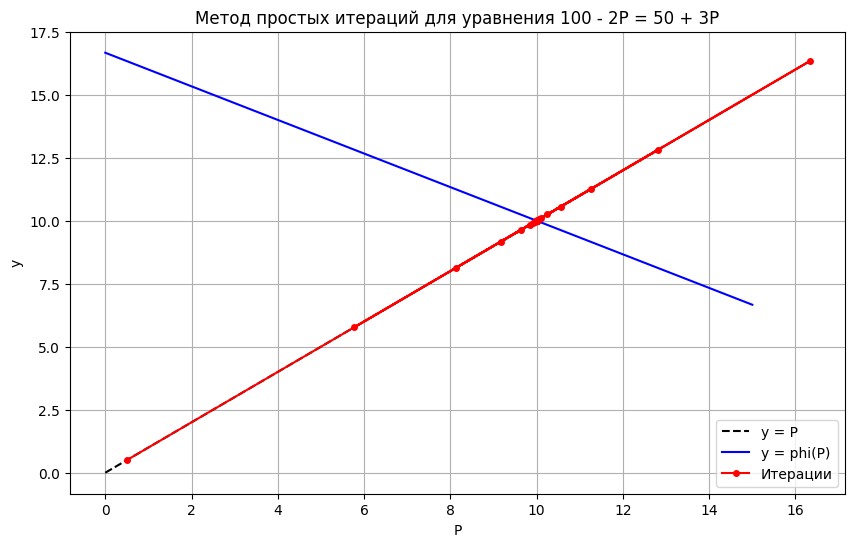

In [19]:
x_vals = np.linspace(0, 15, 100)
plt.figure(figsize=(10, 6))


plt.plot(x_vals, x_vals, 'k--', label='y = P')
plt.plot(x_vals, phi(x_vals), 'b-', label='y = phi(P)')
plt.plot(iterations, iterations, 'ro-', markersize=4, label='Итерации')

plt.xlabel('P')
plt.ylabel('y')
plt.title('Метод простых итераций для уравнения 100 - 2P = 50 + 3P')
plt.legend()
plt.grid(True)
plt.show()

***Ответ:***

Метод простых итераций — это один из фундаментальных способов решения уравнений, основанный на принципе сжимающих отображений. Идея метода заключается в замене исходного уравнения $f(x) = 0$ эквивалентным уравнением $x = \varphi(x)$.

Как это работает:

1. Преобразуем исходное уравнение $f(x) = 0$ к виду $x = \varphi(x)$. Например, для уравнения $x^3 - x - 1 = 0$ можно выбрать $\varphi(x) = \sqrt[3]{x + 1}$ или $\varphi(x) = x^3 - 1$.

2. Выбираем начальное приближение $x_0$.

3. Строим итерационную последовательность: $x_{n+1} = \varphi(x_n)$.

4. Процесс продолжается до выполнения критерия остановки: $|x_{n+1} - x_n| < \varepsilon$.

## Задание 3

В физике находят пересечение кривых:
$$y = x^3, \quad y = 4 - x$$
методом Ньютона для систем уравнений с начальным приближением $(1, 1)$ и точностью $10^{-6}$.

*Объясните метод Ньютона для систем уравнений.*

**max 4 балла**

---

In [20]:
def newton(f, df, x0, tol, n_iterations=20):
    X = np.zeros((n_iterations + 1, len(x0)))
    X[0, :] = x0

    for i in range(n_iterations):
        fx = f(X[i, :])
        J = df(X[i, :])
        c = np.linalg.solve(J, -fx)
        X[i + 1, :] = X[i, :] + c

        k = 0
        for j in range(len(x0)):
            if abs(X[i + 1, j] - X[i, j]) < tol:
                k += 1
        if k == len(x0):
            break

    return X[:i + 2]

In [21]:
def f(x):
    f = np.zeros_like(x)
    f[0] = x[0]**3 - x[1]
    f[1] = x[0] + x[1] - 4
    return f

In [22]:
def df(x):
    df = np.zeros((len(x), len(x)))
    df[0, 0] = 3 * x[0]**2
    df[0, 1] = -1.0
    df[1, 0] = 1.0
    df[1, 1] = 1.0
    return df

In [23]:
x0 = np.array([1.0, 1.0])
tol = 1e-6

X = newton(f, df, x0, tol)
print(X)
print("Решение:", X[-1])

[[1.         1.        ]
 [1.5        2.5       ]
 [1.38709677 2.61290323]
 [1.37883895 2.62116105]
 [1.3787967  2.6212033 ]
 [1.3787967  2.6212033 ]]
Решение: [1.3787967 2.6212033]


***Ответ:***


Дано начальное приближение $\boldsymbol{x}_0 \implies \boldsymbol{x}_n$. На шаге $n+1$:  

1. Вычислить ${\boldsymbol{f}}(\boldsymbol{x}_n)$.  
2. Вычислить матрицу Якоби $J (\boldsymbol{x}_n)$.  
3. Найти "коррекцию" ${\boldsymbol{c}}$ из уравнения:  
   $$J (\boldsymbol{x}_n) {\boldsymbol{c}} = -{\boldsymbol{f}}(\boldsymbol{x}_n).$$  
4. Обновить приближение:  
   $$\boldsymbol{x}_{n+1} = \boldsymbol{x}_n + {\boldsymbol{c}}.$$  

**Никогда не вычислять обратную матрицу Якоби явно!**  

Метод Ньютона вычислительно затратен, но существует его обобщение в виде метода секущих.

# Демовариант 4


## Задание 1

В обработке сигналов суммируют слабые шумы. Начальная амплитуда $500$, каждый из $10^6$ шагов добавляет $0.00005$.  
Теоретическая сумма приращений: $10^6 \cdot 0.00005 = 50$.  
Вычислите итоговую сумму двумя способами:
- прямое сложение,
- с использованием алгоритма Кахана.

*Что такое потеря точности при работе с числами с плавающей точкой? Как её можно минимизировать?*

**max 3 балла**

---

In [24]:
import numpy as np
from numba import jit

n = 10 ** 6
t = 0.00005
init = 500.0
teor_sum = 50.0


def naive_sum(n, t):
    s = np.float32(0.0)
    for _ in range(n):
        s += t
    return s


@jit(nopython=True)
def kahan_sum(n, t):
    s = np.float32(0.0)
    c = np.float32(0.0)
    for _ in range(n):
        y = t - c
        tmp = s + y
        c = (tmp - s) - y
        s = tmp
    return s


naive_total = init + naive_sum(n, t)
kahan_total = init + kahan_sum(n, t)

print(naive_total, kahan_total)

549.66364 550.0


***Ответ:***

Потеря точности — это ошибка, возникающая из-за того, что числа с плавающей точкой (float) хранятся приближённо, а не точно.

Как минимизировать:
1. использовать более точный тип:
    - `float64` вместо `float32`
    - больше бит вмещается в переменную следовательно меньше ошибка
2. Использовать специальные алгоритмы, как **Алгоритм Кахана**, который сохраняет потерянные маленькие значения и уменьшает накопление ошибки
3. Избегать вычитание близких чисел
4. Менять порядок операций
    - сначала складывать маленькие числа
    - потом большие


## Задание 2

В финансах ищут внутреннюю норму доходности $r$:
$$-1000 + \sum_{t=1}^{5} \frac{300}{(1 + r)^t} = 0$$
Решите уравнение методом Ньютона с начальным приближением $r_0 = 0.1$ и точностью $10^{-3}$.

*Опишите преимущества и недостатки метода Ньютона.*

**max 3 балла**

---


In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def f(r):
    s = -1000
    for t in range(1, 5+1):
        s += 300 / (1 + r) ** t
    return s

In [27]:
def df(r):
    s = 0
    for t in range(1, 5+1):
        s += -300 * t / (1 + r) ** (t + 1)
    return s

In [28]:
def newton_raphson(x0, tol=1e-6, max_iter=10):
    x_vals = [x0]
    for _ in range(max_iter):
        if abs(f(x_vals[-1])) < tol:
            break
        x_next = x_vals[-1] - f(x_vals[-1]) / df(x_vals[-1])
        x_vals.append(x_next)
    return x_vals

In [29]:
r0 = 0.1
x_vals = newton_raphson(r0)
print(x_vals)
print("IRR=", x_vals[-1])

[0.1, 0.14723723146091863, 0.1523315514932577, 0.15238236619611117, 0.15238237116630643]
IRR= 0.15238237116630643


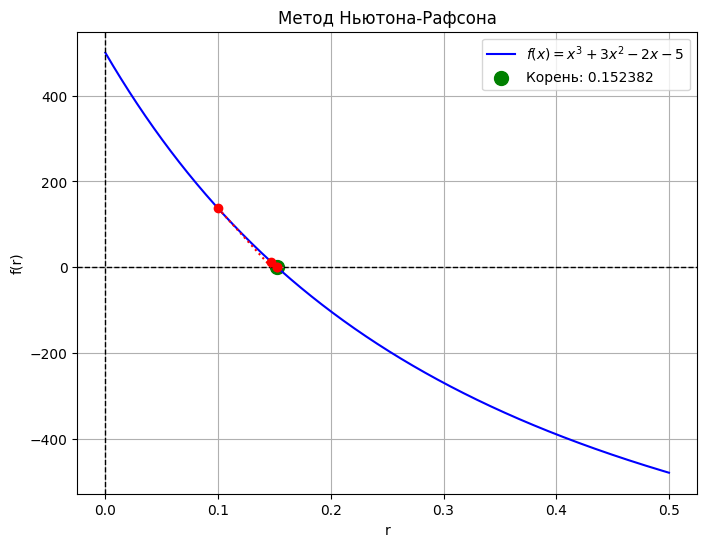

In [30]:
x_range = np.linspace(0, 0.5, 1000)
y_range = f(x_range)

x0 = 0.1
steps = newton_raphson(x0)

plt.figure(figsize=(8, 6))
plt.plot(x_range, y_range, label=r"$f(x) = x^3 + 3x^2 - 2x - 5$", color="blue")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.axvline(0, color="black", linewidth=1, linestyle="--")

for i in range(len(steps) - 1):
    x_prev, x_next = steps[i], steps[i+1]
    plt.scatter([x_prev], [f(x_prev)], color="red", zorder=3)  # Отмечаем точки
    plt.plot([x_prev, x_next], [f(x_prev), 0], color="red", linestyle="dotted")  # Касательные линии

root = steps[-1]
plt.scatter([root], [0], color="green", s=100, label=f"Корень: {root:.6f}")

plt.xlabel("r")
plt.ylabel("f(r)")
plt.title("Метод Ньютона-Рафсона")
plt.legend()
plt.grid(True)
plt.show()

***Ответ:***


Преимущества метода Ньютона:

* **Быстрая сходимость** (квадратичная) при хорошем начальном приближении
* Требует **малое число итераций**
* Даёт **высокую точность решения**

---

Недостатки:

* Нужно вычислять **производную** (или Якобиан для систем)
* Может **расходиться** при плохом начальном приближении
* Проблемы, если ($f'(x) \approx 0$) (деление на маленькое число)
* Требует, чтобы функция была **достаточно гладкой**


## Задание 3

В экономике решают систему:
$$x = 2y - y^2, \quad y = x - 0.5x^2$$
Найдите $(x, y)$ методом функциональной итерации с точностью $10^{-3}$.

*Объясните метод функциональной итерации для систем.*

**max 4 балла**

---

In [31]:
def fn_iteration(g, x0, tol, n_iterations=20):
    A = np.zeros((n_iterations + 1, len(x0)))
    A[0, :] = x0

    for i in range(n_iterations):
        A[i + 1, :] = g(A[i, :])

        k = 0
        for j in range(len(x0)):
            if abs(A[i + 1, j] - A[i, j]) < tol:
                k += 1
        if k == len(x0):
            break

    return A[:i + 2]

In [32]:
def g(x):
    res = np.zeros_like(x)
    res[0] = 2 * x[1] - x[1]**2
    res[1] = x[0] - 0.5 * x[0]**2
    return res

In [33]:
x0 = np.array([0.5, 0.5])
result = fn_iteration(g, x0, 1e-3)

print(result)
print("Решение:", result[-1])

[[0.5        0.5       ]
 [0.75       0.375     ]
 [0.609375   0.46875   ]
 [0.71777344 0.42370605]
 [0.66788529 0.46017408]
 [0.70858798 0.44484991]
 [0.69180838 0.45753952]
 [0.70573662 0.45250896]
 [0.70025356 0.45670453]
 [0.70483004 0.45507604]
 [0.70305787 0.45643735]
 [0.70453964 0.45591269]
 [0.703969   0.45635159]]
Решение: [0.703969   0.45635159]


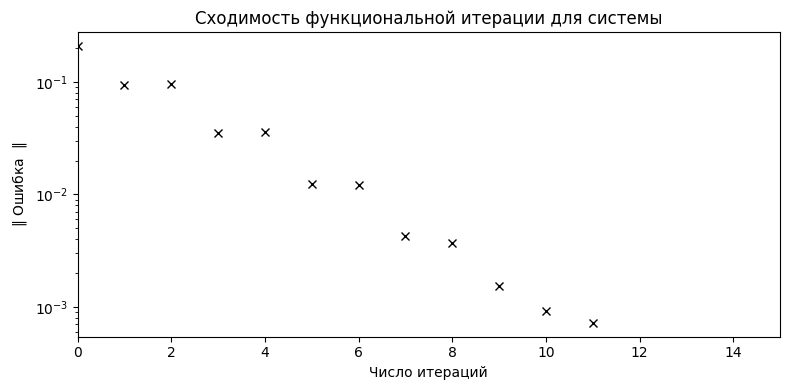

In [34]:
# Построение графика сходимости
iters = range(len(result))
errors = np.linalg.norm(result-result[-1,:],2,axis=1)

fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(111)
ax.semilogy(iters, errors, 'kx')
ax.set_xlabel("Число итераций")
ax.set_ylabel(r"$\|$ Ошибка  $\|$")
ax.set_xbound(0.0,15.0)
ax.set_title("Сходимость функциональной итерации для системы")
fig.tight_layout()
plt.show()

***Ответ:***

**Идея:** Мы преобразуем нашу исходную систему $f(x) = 0$ в эквивалентную форму $x = g(x)$. Тогда решение $s$ (неподвижная точка) ищется с помощью итерационного процесса:
$x_{n+1} = g(x_n)$, начиная с некоторого начального приближения $x_0$.

**Сжимающее отображение:** Чтобы этот процесс гарантированно сходился к единственному решению, отображение g должно быть "сжимающим" в некоторой области $I$. Это значит:

**Замкнутость:** Если мы применяем $g$ к любой точке из $I$, результат тоже остается в $I$ $(g(I) ⊆ I)$.
Сжатие: Отображение уменьшает расстояние между любыми двумя точками. Формально это условие Липшица с константой $L < 1$:

$||g(x) - g(y)|| ≤ L ||x - y||$ для всех $x, y ∈ I.$

**Зачем это нужно?** Теорема о сжимающем отображении гарантирует, что если g сжимающее, то *существует единственная неподвижная точка в $I$.*

Итерационный процесс $x_{n+1} = g(x_n)$ сойдется к этой точке из любого начального приближения в I.

Мы даже можем оценить скорость сходимости и ошибку.

**Проверка условия сжатия на практике:** Как проверить, является ли сложная вектор-функция g сжимающей? Здесь на помощь приходит производная, а в многомерном случае — **Якобиан.**

# Демовариант 5


## Задание 1

В анализе данных о ежедневных расходах небольшого бизнеса необходимо суммировать затраты за месяц. Ежедневный расход составляет $0.03$ условных единицы, а в каждом месяце — $10^4$ дней. Вычислите сумму двумя способами:
- обычное сложение в цикле,
- с использованием алгоритма Кахана.

*Что такое ошибка округления в вычислениях с плавающей точкой и как алгоритм Кахана помогает её уменьшить?*

**max 3 балла**

---

In [35]:
def common_sum(inp):
  s = 0.0
  for i in inp:
    s += i
  return s

def kahan_sum(inp):
  s = 0.0
  c = 0.0
  for i in range(len(inp)):
    y = inp[i] - c
    t = s + y
    c = (t - s) - y
    # print(c)
    s = t
  return s

In [36]:
a = [0.03 for i in range(10 ** 2)]
com, kah = common_sum(a), kahan_sum(a)
com, kah

(2.999999999999995, 3.0)

**Ответ:** Ошибка округления - потеря точности числа с плавающей точкой, когда его сохраняют в ограниченное кол-во бит

 Алгоритм Кахана позволяет уменьшить **ошибку округления** до $2 \varepsilon + \mathcal{O}(n \varepsilon^2)$ где $\varepsilon$ — машинная точность.

Идея: хранить отдельную переменную c, которая «запоминает» младшие биты, потерянные при округлении.

## Задание 2

В экономике ищут максимум прибыли:
$$\pi(x) = -x^3 + 3x^2 + 9x - 10$$
Найдите $x$, где $\pi'(x) = 0$, методом модифицированного Ньютона с точностью $10^{-6}$.

*Опишите модифицированный метод Ньютона и его преимущества.*

**max 3 балла**

---

In [37]:
def f(x):
  return -3 * x ** 2 + 6 * x + 9
def df(x):
  return -6 * x  + 6

In [38]:
def f_nuton(x, tol=10 ** (-6)):
  hist = [x]
  df_x0 = df(x)
  while abs(f(x)) > tol:
    x = x - f(x) / df_x0
    hist.append(x)
  return np.array(hist)

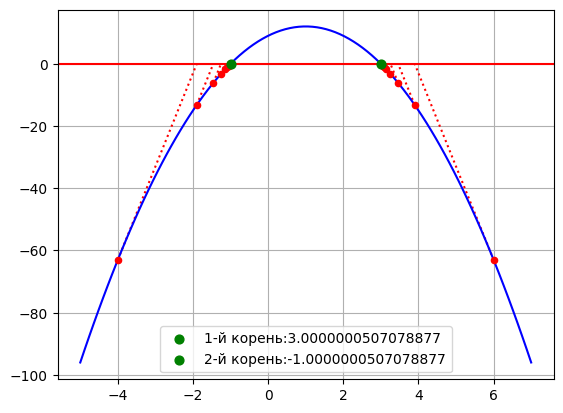

In [39]:
x = np.linspace(-5, 7, 100)

steps = f_nuton(6)
for i in range(len(steps) - 1):
  x_prev = steps[i]
  x_next = steps[i+1]
  plt.scatter([x_prev], [f(x_prev)], color="red", zorder=3, s=20)
  plt.plot([x_prev, x_next], [f(x_prev), 0], color="red", linestyle="dotted")
plt.scatter([steps[-1]], [f(steps[-1])], color="green", zorder=3, s=40, label=f'1-й корень:{steps[-1]}')
# plt.scatter(history, f(history), color='r')

steps = f_nuton(-4)
for i in range(len(steps) - 1):
  x_prev = steps[i]
  x_next = steps[i+1]
  plt.scatter([x_prev], [f(x_prev)], color="red", zorder=3, s=20)
  plt.plot([x_prev, x_next], [f(x_prev), 0], color="red", linestyle="dotted")
plt.scatter([steps[-1]], [f(steps[-1])], color="green", zorder=3, s=40, label=f'2-й корень:{steps[-1]}')
plt.axhline(0, color='red')
plt.legend()
plt.plot(x, f(x), color="blue")
plt.grid()

**ОТВЕТ** основная идея модифицированного метода ньятона - вычислять x_i на каждой итерации как $$x_i = x_{i-1} - \frac{f(x_{i-1})}{f'(x_{i-1})}$$

**преимущества** - не надо вычислять f'(x) на каждой итерации, вычисляется только f'(x_0), от чего идет экономия ресурсов, если f'(x) - сложная и вычислительно затратная

## Задание 3

В анализе данных предсказывают продажи: $(1, 100)$, $(2, 150)$, $(3, 200)$, $(4, 250)$ (день, продажи). Найдите продажи в день $2.5$ полиномом Лагранжа.

*Что такое интерполяционный полином Лагранжа?*

**max 4 балла**

In [40]:
def p(x, x_, i):
  a = 1
  for j in range(len(x)):
    if j != i:
      a *= (x_ - x[j]) / (x[i] - x[j])
  return a
def l(x, y, x_):
  s = 0
  for i in range(len(x)):
    s += y[i] * p(x, x_, i)
  return s

175.0

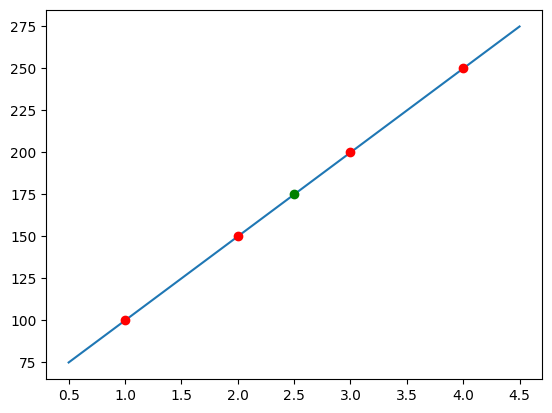

In [41]:
x_target = 2.5
x = [1, 2, 3, 4]
y = [100, 150, 200, 250]
result = l(x, y, x_target)
x_for_graph = np.linspace(min(x) - 0.5, max(x) + 0.5, 200)

plt.plot(x_for_graph, [l(x, y, i) for i in x_for_graph])
plt.scatter(x_target, result, color='green', zorder=2)
plt.scatter(x, y, color='red', zorder=2)
result

**ОТВЕТ** интерполяционный полином Лагранжа - многочлен L(x), который проходит через все заданные точки, используется для приближенного нахождения функции в промежуточных точках L(x) = sum(from i=0 to n, y_i * l_i(x))

$$L(x) = \sum_{i=0}^{n} y_i \cdot \ell_i(x)$$

$$\ell_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}$$

где x без индекса - промежуточная точка

**преимущества:** не требует решения системы уравнений

**недостатки:** сложность O(n^2), рпи добавлении новой точки нужен пересчет всех l_i

# Демовариант 6

## Задание 1

В физике считают силу гравитации между $10^6$ телами массой $1$ кг на расстоянии $1$ м. Каждое тело взаимодействует со всеми остальными, общее число взаимодействий $N(N-1)/2 \approx 5 \times 10^{11}$. Вычислите общую силу по формуле $F = G \cdot m_1 m_2 / r^2$, где $G = 6.67 \times 10^{-11}$, используя обычное суммирование и суммирование по Кахану. Сравните результаты с теоретическим значением.

*Что такое стандарт IEEE 754 и как он влияет на точность вычислений?*

**max 3 балла**


In [42]:
def common_sum(inp):
  s = 0
  for i in inp:
    s += i
  return s
def kah_sum(inp):
  s = 0
  c = 0
  for i in inp:
    y = i - c
    t = s + y
    c = (t - s) - y
    s = t
  return s
def f(m1, m2, r):
  return 6.67 * 10 ** (-11) * m1 * m2 / (r ** 2)

In [43]:
n = 10 ** 3 # n меньше ибо 10 ** 6 - пиздец
x = [f(1, 1, 1) for i in range(n * (n - 1))]
common = common_sum(x)
kah = kah_sum(x)
common, kah,

(6.663330000065089e-05, 6.66333e-05)

**ОТВЕТ** **IEEE 754** — это стандарт представления чисел с плавающей запятой в компьютерах, определяющий правила округления, обработку исключений


**влияение на точность:** Потеря значимости при вычитании близких чисел, ошибка округления, предельная конечная точность

число можно представить в виде  $n = (-1)^s 2^{e-1023} (1+f).$

## Задание 2

В финансах ищут внутреннюю норму доходности облигации:
$$950 = \sum_{t=1}^{5} \frac{50}{(1 + r)^t} + \frac{1000}{(1 + r)^5}$$
Найдите $r$ методом бисекции на интервале $[0, 0.1]$ с точностью $10^{-6}$.

*Опишите сходимость метода бисекции.*

**max 3 балла**

In [44]:
def f(r):
  s = 1000 / (1 + r) ** 5 - 950
  for t in range(1, 5+1):
    s += 50 / (1 + r) ** t
  return s

In [45]:
def bisec(f, a=0, b=0.1, tol=10 ** (-6), max_iter=50):
  if np.sign(f(a)) == np.sign(f(b)):
    raise ValueError("знаки функции должны быть разные")
  history = []
  for i in range(max_iter):
    c = (a + b) / 2
    fc = f(c)
    history.append((a, b, c, fc))
    if abs(fc) < tol or (b - a)/2 < tol:
      break
    if f(a) * fc < 0:
      b = c
    else:
      a = c
  return history
def plot_bisec(history, f, a0, b0):
  x = np.linspace(-0.02, 0.12, 100)
  y = f(x)

  plt.plot(x, y)
  plt.axvline(a0, linestyle='--')
  plt.axvline(b0, linestyle='--')
  for i, (a, b, c, fc) in enumerate(history):
    plt.plot(c, fc, 'ro')
    plt.plot([c, c], [0, fc], linestyle = '--')
    plt.text(c, fc, f' {i}')
  plt.grid()

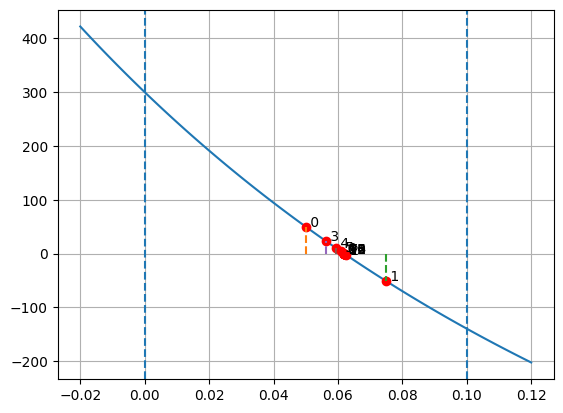

In [46]:
hist_bis = bisec(f, 0, 0.1)
plot_bisec(hist_bis, f, 0, 0.1)

**ОТВЕТ** Метод биссекции обладает **линейной сходимостью** (ошибка на каждой итерации уменьшается в постоянное число раз, при c = (a + b) / 2 - в 2 раза соответственно)

## Задание 3

В экономике анализируют два рынка:
$$Q_{d1} = 100 - P_1 + 0.5P_2, \quad Q_{s1} = 50 + 0.5P_1$$
$$Q_{d2} = 80 - P_2 + 0.5P_1, \quad Q_{s2} = 40 + 0.5P_2$$
Найдите равновесные цены $P_1$, $P_2$ методом функциональной итерации с начальным приближением $(10, 10)$ и точностью $10^{-3}$.

*Объясните метод функциональной итерации для систем уравнений.*

**max 4 балла**

**ИДЕЯ** равновесные P1, P2 - когда Qd1 = Qs1, Qd2 = Qs2

и после этого выражаем P1, P2 из получившихся уравнений


In [47]:
def g(x):
    p1, p2 = x
    return np.array([25 + p2/3, 20 + p1/3], dtype=float)
def fn_iteration(g, x0, tol=10**(-3), n_iterations = 20):
  A = np.zeros((n_iterations + 1, len(x0)))
  A[0, :] = x0

  for i in range(n_iterations):
    A[i+1, :] = g(A[i, :])
    k = 0
    for j in range(len(x0)):
      if (abs(A[i+1, j] - A[i, j]) < tol):
        k += 1
    if (k == len(x0)):
      break

  return A[:i + 2, :] # :i+2 - чтобы не захватывать нулевые строки, которые не были затронуты

In [48]:
x0 = [10, 10]
result = fn_iteration(g, x0)
result

array([[10.        , 10.        ],
       [28.33333333, 23.33333333],
       [32.77777778, 29.44444444],
       [34.81481481, 30.92592593],
       [35.30864198, 31.60493827],
       [35.53497942, 31.76954733],
       [35.58984911, 31.84499314],
       [35.61499771, 31.86328304],
       [35.62109435, 31.8716659 ],
       [35.62388863, 31.87369812],
       [35.62456604, 31.87462954]])

Text(0, 0.5, 'ошибка')

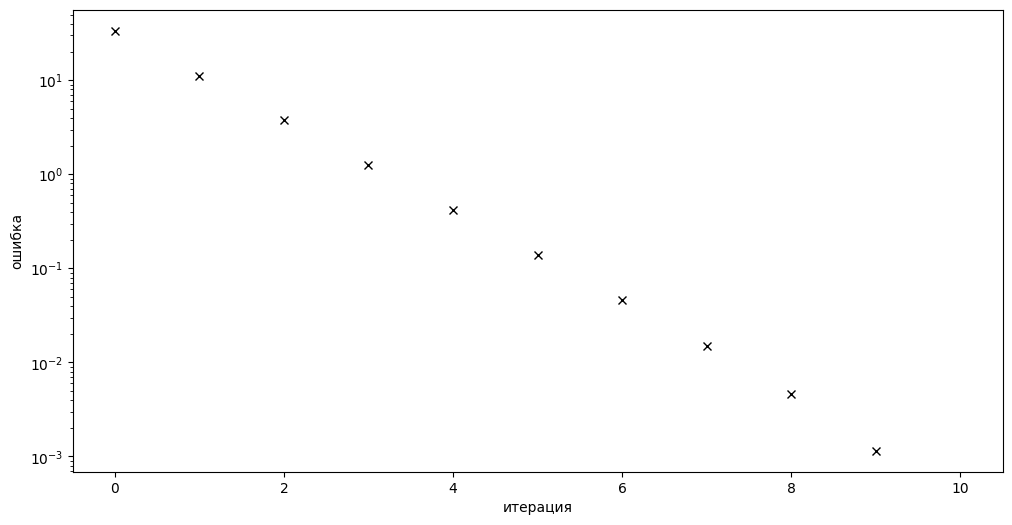

In [49]:
iters = range(len(result))
err = np.linalg.norm(result-result[-1,:], 2, axis=1)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.semilogy(iters, err, 'kx')
ax.set_xlabel('итерация')
ax.set_ylabel('ошибка')

**ОТВЕТ** Метод функциональной итерации — это когда систему переписывают в виде
x=g(x), а потом многократно подставляют начальное приближение в правую часть:
$$x^{(k+1)} = g\!\left(x^{(k)}\right)$$

Если последовательность сходится, её предел и есть решение системы

# Демовариант 7

## Задание 1

В анализе данных считают корреляцию двух массивов по $10^6$ элементов, каждый из которых равен $1.000001$. Корреляция вычисляется как $\frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$. Вычислите сумму произведений пар элементов этих массивов двумя способами: обычным суммированием и суммированием по Кахану. Сравните результаты.

*Что такое ошибка представления чисел с плавающей точкой и как она влияет на вычисления?*

**max 3 балла**

---

In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# 1
a = np.full(10**6, 1.000001)
b = np.full(10**6, 1.000001)

In [52]:
mult_ab = a * b
ordinary_sum = np.sum(mult_ab)
ordinary_sum

np.float64(1000002.0000010012)

In [53]:
# функция суммирования по Кахану
def Kahan(nums):
  s = np.float64(0.0)
  c = np.float64(0.0)
  for i in range(len(nums)):
    y = nums[i] - c
    t = s + y
    c = (t-s) - y
    s = t
  return s

In [54]:
Kahan(mult_ab)

np.float64(1000002.0000009999)

Наиболее распространённый вид ошибки округления — это ошибка представления (representation error), связанная с представлением чисел с плавающей запятой.

Простой пример — число  π . Мы знаем, что оно имеет бесконечное число знаков после запятой. Однако на практике мы используем только его конечное представление, например, 3.14159265. Разница между этим значением и истинным  π  является ошибкой округления.

## Задание 2

В физике при изучении охлаждения объекта температура $T(t)$ изменяется по закону:
$$T(t) = T_0 e^{-kt} + T_{\text{env}}$$
где $T_0 = 80$ °C — начальная разность температур, $k = 0.1$ 1/мин — коэффициент охлаждения, $T_{\text{env}} = 20$ °C — температура окружающей среды. Найдите время $t$, через которое температура достигнет $40$ °C, методом секущих с точностью $10^{-6}$.

*Детально опишите скорость сходимости метода секущих и метода Ньютона. Когда метод секущих более предпочтителен?*

**max 3 балла**

---


In [55]:
# 2
T0 = 80
k = 0.1
T_env = 20
T_t = 40
tol = 1e-06

In [56]:
def f(t):
    return 80 * np.exp(-0.1 * t) - 20

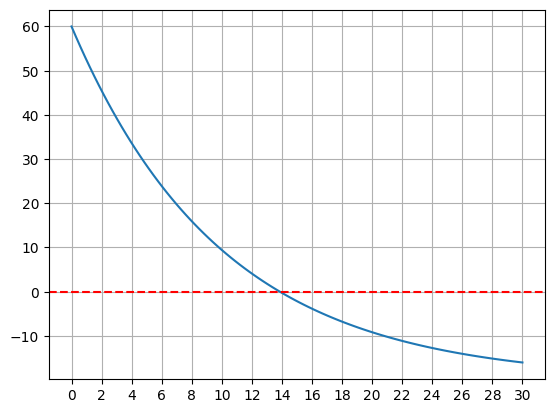

In [57]:
t = np.linspace(0, 30, 100)
y = f(t)

plt.plot(t, y)
plt.axhline(color='r', linestyle='--')
plt.xticks(np.arange(0, 31, 2))
plt.grid(True)
plt.show()

In [58]:
# Делаем вывод, что надо искать между 13 и 15

In [59]:
def secant_method(f, t0, t1, tol=1e-6, max_iter=100):
  iterations = [t0, t1]
  for i in range(2, max_iter):
    x_prev = iterations[-2]
    x_cur = iterations[-1]
    f_prev = f(x_prev)
    f_cur = f(x_cur)
    if abs(f_cur - f_prev) < 1e-15:
      print('Не сошлось, почти 0')
      return x_cur, iterations
    x_next = x_cur - f_cur * (x_cur - x_prev) / (f_cur - f_prev)
    iterations.append(x_next)
    error = abs(x_next - x_cur)
    if error < tol:
      return x_next, iterations

In [60]:
root, iterations = secant_method(f, 13, 15)

In [61]:
root

np.float64(13.862943611198904)

In [62]:
def secant_plot(f, t0, t1):
  x = np.linspace(0, 30, 100)
  y = f(x)
  plt.plot(t, f(t), 'b-')
  plt.axhline(y=0, color='r', linestyle='--')
  plt.grid(True)
  plt.xlabel('t (мин)')
  plt.ylabel('f(t)')

  plt.plot([t0, t1], [f(t0), f(t1)], 'ro-')
  t2 = t1 - f(t1) * (t1 - t0) / (f(t1) - f(t0))
  plt.plot([t1, t2], [f(t1), 0], 'go-')

  plt.show()
  print(f"Корень: {t2:.6f}")

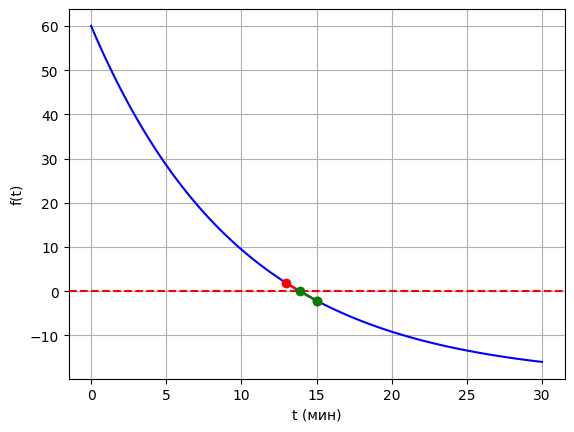

Корень: 13.912188


In [63]:
secant_plot(f, 13, 15)

## Задание 3

В финансах строят кривую доходности: $(1, 0.02)$, $(2, 0.025)$, $(5, 0.03)$ (годы, доходность). Найдите доходность для $3$ лет линейной интерполяцией.

*Что такое глобальная и локальная интерполяция?*

**max 4 балла**

In [64]:
#3
x = [1, 2, 5] # сюда идут года
y = [0.02, 0.025, 0.03] # сюда идет доходность

In [65]:
def linear_interpolation(x_values, y_values, x_new):
  for i in range(len(x_values)-1):
    if x_new >= x_values[i] and x_new <= x_values[i+1]:
      y_new = y_values[i] + (y_values[i+1] - y_values[i])*(x_new - x_values[i]) /(x_values[i+1] - x_values[i])
      return y_new
  return None

In [66]:
y_hat = linear_interpolation(x, y, 3)
print(y_hat)

0.02666666666666667


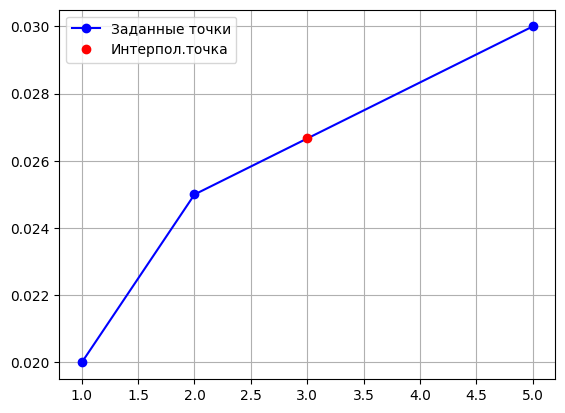

In [67]:
plt.plot(x, y, '-ob', label='Заданные точки')
plt.plot(3, y_hat, 'ro', label='Интерпол.точка')
plt.grid(True)
plt.legend()
plt.show()

**Локальная интерполяция** — для вычисления значения в точке используются только ближайшие соседние точки. Пример: линейная интерполяция между двумя соседними узлами. Просто и быстро, но на стыках интервалов может быть излом.

**Глобальная интерполяция** — для вычисления значения используются **все** известные точки сразу. Строится один многочлен (например, полином Ньютона или Лагранжа), проходящий через все точки. Даёт гладкую кривую, но при большом количестве точек может сильно колебаться между ними.

# Демовариант 8


## Задание 1

В экономике считают инфляцию за $10^6$ месяцев при постоянном ежемесячном росте цены потребительской корзины на $0.001\%$. Итоговый коэффициент вычисляется как $(1 + 0.00001)^{10^6}$. Вычислите этот коэффициент, используя логарифмирование: $\exp(10^6 \cdot \ln(1 + 0.00001))$, чтобы избежать underflow.

*Как избежать underflow в вычислениях?*

**max 3 балла**

---

In [68]:
#1
np.exp(10**6 * np.log(1+0.00001))

np.float64(22025.364507834238)

underflow - это когда число становитс настолько маленьким, что не помещается во float и обнуляется
как избежать: перейти в логарифмическую шкалу, использовать типы с большей разрядностью, масштабировать данные перед использованием

## Задание 2

Найдите корень уравнения:
$$x^3 - 3x + 1 = 0$$
методом секущих на интервале $[0, 1]$ с точностью $10^{-6}$.

*Опишите метод секущих и его отличие от метода Ньютона.*

**max 3 балла**

---

In [69]:
# 2
def f(x):
  return x**3 - 3 * x + 1

In [70]:
def secant_method(f, x0, x1, max_iter=100, tol=1e-06):
  iterations = [x0, x1]
  for i in range(2, max_iter):
    x_prev = iterations[-2]
    x_cur = iterations[-1]
    f_prev = f(x_prev)
    f_cur = f(x_cur)
    if abs(f_cur - f_prev) < 1e-15:
      print('Близко к 0, почти деление на 0')
      return x_cur, iterations
    x_next = x_cur  - f_cur * (x_cur - x_prev) / (f_cur - f_prev)
    iterations.append(x_next)
    error = abs(x_next - x_cur)
    if error < tol:
      return x_next, iterations

In [71]:
root, iterations = secant_method(f, 0, 1)

In [72]:
root

0.3472963553338609

In [73]:
iterations

[0,
 1,
 0.5,
 0.2,
 0.3563218390804598,
 0.3477313259190656,
 0.347294784910048,
 0.34729635560379174,
 0.3472963553338609]

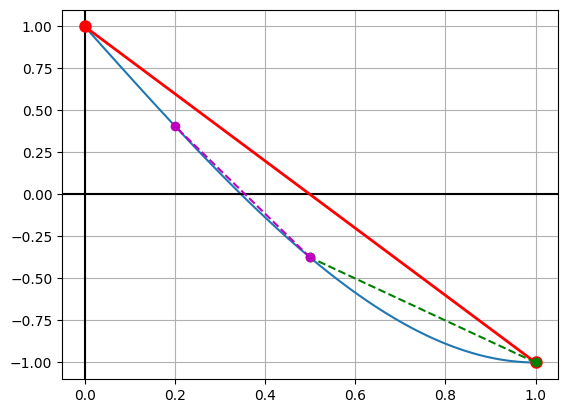

0.3472963553338609


In [74]:
x = np.linspace(0, 1, 100)
y = f(x)
x0 = 0
x1 = 1
plt.plot(x, y)
plt.axhline(color='k', linestyle='-')
plt.axvline(color='k', linestyle='-')
plt.plot([x0, x1], [f(x0), f(x1)], 'r-o', linewidth=2, markersize=8)
# first iteration
x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
plt.plot([x1, x2], [f(x1), f(x2)], 'g--o')
# second iteration
x3 = x2 - f(x2) * (x2 - x1) / (f(x2) - f(x1))
plt.plot([x2, x3], [f(x2), f(x3)], 'm--o')

plt.grid(True)
plt.show()
print(root)

Метод секущих: берём два начальных приближения, например концы интервала, где находится корень. Через две последние точки на графике функции проводим прямую, которую называют секущей. Находим, где эта прямая пересекает ось икс - это и есть новое приближение корня. Затем отбрасываем самую старую точку и повторяем процесс с новой парой точек.

Метод Ньютона требует знания производной, зато он очень быстрый - точность удваивается с каждым шагом. Метод секущих медленнее, точность растёт не так резко, зато производная не нужна.

## Задание 3

В физике ищут равновесие пружин:
$$2x_1 + 3(x_1 - x_2) = 0$$
$$3(x_2 - x_1) + 4x_2 = 0$$
Решите систему методом Гаусса–Зейделя с точностью $10^{-6}$.

*Объясните метод Гаусса–Зейделя для решения систем линейных уравнений.*

**max 4 балла**

In [75]:
# Приводим к виду, удобному для метода Гаусса-Зейделя:
# x1 = (3/5) * x2
# x2 = (3/7) * x1

def gauss_seidel(tol=1e-6, max_iter=100):
    x1 = 0.0  # начальное приближение
    x2 = 0.0
    for i in range(max_iter):
        x1_old = x1
        x2_old = x2
        x1 = (3/5) * x2
        # Обновляем x2, используя уже обновлённое x1
        x2 = (3/7) * x1
        # Ошибка — максимальное изменение между итерациями
        error = max(abs(x1 - x1_old), abs(x2 - x2_old))
        if error < tol:
            break

    return x1, x2
x1, x2 = gauss_seidel()
print(f"\nРешение:")
print(f"x1 = {x1:.10f}")
print(f"x2 = {x2:.10f}")


Решение:
x1 = 0.0000000000
x2 = 0.0000000000


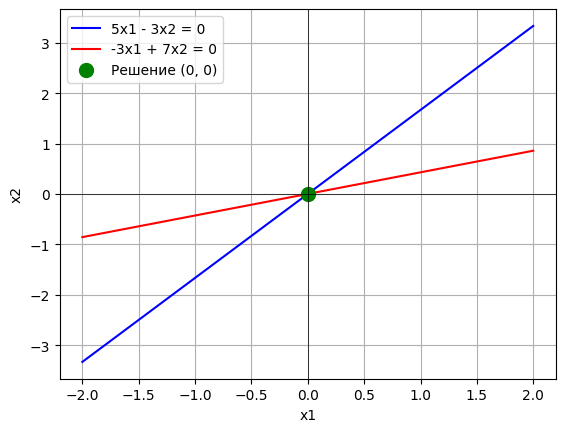

In [76]:
import numpy as np
import matplotlib.pyplot as plt


x1 = np.linspace(-2, 2, 100)

# Выражаем x2 из каждого уравнения
x2_line1 = (5/3) * x1      # из 5x1 - 3x2 = 0
x2_line2 = (3/7) * x1      # из -3x1 + 7x2 = 0
plt.plot(x1, x2_line1, 'b-', label='5x1 - 3x2 = 0')
plt.plot(x1, x2_line2, 'r-', label='-3x1 + 7x2 = 0')
plt.plot(0, 0, 'go', markersize=10, label='Решение (0, 0)')

plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.grid(True)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

Метод Гаусса-Зейделя это итерационный метод для решения систем линейных уравнений. На каждом шаге вы по очереди уточняете каждую неизвестную, сразу используя уже обновлённые значения.

Как он работает. Берёте начальное приближение, обычно нули. Затем для первой неизвестной выражаете её из первого уравнения и вычисляете, используя текущие значения остальных переменных. Потом для второй неизвестной выражаете её из второго уравнения и вычисляете, используя уже обновлённое значение первой и старые значения остальных. Так проходите по всем неизвестным. После этого повторяете весь цикл заново. Процесс останавливается, когда изменения между итерациями становятся меньше заданной точности.

# Демовариант 9


## Задание 1

В финансах считают стоимость портфеля из $10^6$ активов, стоимость каждого — $1.000001$. Найдите сумму двумя способами: обычным суммированием и суммированием по Кахану. Сравните результаты.

*Как суммирование по Кахану улучшает точность вычислений?*

In [77]:
import numpy as np

# Обычное суммирование
def naive_summation(values):
    s = np.float32(0.0)
    for x in values:
        s += x
    return s

# Суммирование по алгоритму Кахана
def kahan_summation(values):
    s = np.float32(0.0)
    c = np.float32(0.0)  # компенсатор погрешностей
    for x in values:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

In [78]:
N = 10**6
value = np.float32(1.000001)

# Создаём массив
values = [value] * N

# Точная сумма
exact_sum = N * 1.000001

# Вычисляем
sum_naive = naive_summation(values)
sum_kahan = kahan_summation(values)

print(f"Точная сумма:        {exact_sum:.10f}")
print(f"Обычное суммирование: {sum_naive:.10f}")
print(f"Суммирование Кахана:  {sum_kahan:.10f}")

Точная сумма:        1000000.9999999999
Обычное суммирование: 1000000.0625000000
Суммирование Кахана:  1000000.9375000000


При обычном суммировании при сложении большого и маленького числа теряется точность, так как маленькое число выходит за пределы машинной точности. Алгоритм Кахана решает эту проблему, сохраняя потерянную часть в отдельной переменной-компенсаторе и добавляя её на следующем шаге. Это позволяет накапливать сумму с высокой точностью, не теряя малые приращения. В результате ошибка округления становится близкой к машинной точности, а не растёт с числом слагаемых.

## Задание 2

В экономике ищут равновесие:
$$\frac{100}{p} = p^2$$
Найдите $p$ методом бисекции на интервале $[1, 10]$ с точностью $10^{-6}$.

*Опишите, в каких случаях метод бисекции более предпочтителен, нежели методы функциональных итераций.*

In [79]:
import numpy as np

def bisection(f, a, b, tol=1e-6, max_iter=50):
    if np.sign(f(a)) == np.sign(f(b)):
        raise Exception("Заданные a и b не ограничивают корень")

    history = []

    for _ in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        history.append((a, b, c, fc))

        if abs(fc) < tol or (b - a)/2 < tol:
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return history

# Уравнение: 100/p = p^2  →  p^3 = 100  →  p = ∛100
def f(p):
    return 100/p - p**2

# Поиск корня
a, b = 1.0, 10.0
history = bisection(f, a, b, tol=1e-6)

# Вывод результатов
print(f"{'Итерация':<10} {'a':<15} {'b':<15} {'c':<15} {'f(c)':<15}")
print("-" * 70)

for i, (a_val, b_val, c_val, fc) in enumerate(history, 1):
    print(f"{i:<10} {a_val:<15.10f} {b_val:<15.10f} {c_val:<15.10f} {fc:<15.2e}")

# Корень
c_root = history[-1][3]
p_root = history[-1][2]
print("\n" + "="*70)
print(f"Найденный корень: p = {p_root:.10f}")
print(f"Значение функции: f(p) = {f(p_root):.2e}")
print(f"Проверка: 100/p = {100/p_root:.10f}, p² = {p_root**2:.10f}")
print(f"Аналитический корень: ∛100 = {100**(1/3):.10f}")

Итерация   a               b               c               f(c)           
----------------------------------------------------------------------
1          1.0000000000    10.0000000000   5.5000000000    -1.21e+01      
2          1.0000000000    5.5000000000    3.2500000000    2.02e+01       
3          3.2500000000    5.5000000000    4.3750000000    3.72e+00       
4          4.3750000000    5.5000000000    4.9375000000    -4.13e+00      
5          4.3750000000    4.9375000000    4.6562500000    -2.04e-01      
6          4.3750000000    4.6562500000    4.5156250000    1.75e+00       
7          4.5156250000    4.6562500000    4.5859375000    7.75e-01       
8          4.5859375000    4.6562500000    4.6210937500    2.85e-01       
9          4.6210937500    4.6562500000    4.6386718750    4.06e-02       
10         4.6386718750    4.6562500000    4.6474609375    -8.18e-02      
11         4.6386718750    4.6474609375    4.6430664062    -2.06e-02      
12         4.6386718750    4.

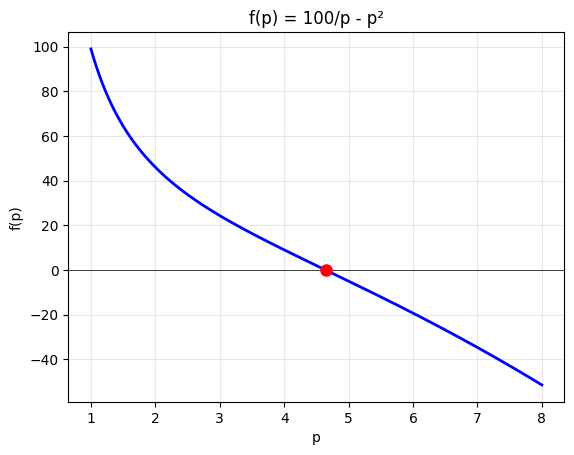

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def f(p):
    return 100/p - p**2

# Точка корня
f_root = f(p_root)

# Данные для графика
p = np.linspace(1, 8, 500)
y = f(p)

# Рисуем
plt.plot(p, y, 'b-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.plot(p_root, f_root, 'ro', markersize=8)  # Вставляем точку

# Подписи
plt.xlabel('p')
plt.ylabel('f(p)')
plt.title('f(p) = 100/p - p²')
plt.grid(True, alpha=0.3)

plt.show()

Метод бисекции более предпочтителен, когда функция негладкая, немонотонная или трудно вычислить производную, так как он не требует производной и гарантированно сходится при любом начальном интервале, содержащем корень. Он также надёжен при плохом начальном приближении, даёт точную оценку погрешности на каждом шаге и требует лишь одного вычисления функции на итерацию. Главный недостаток — медленная линейная сходимость, но в задачах, где важна гарантия результата, а не скорость, бисекция часто оказывается лучшим выбором.

## Задание 3

Предскажите население в $2015$ году: $(2000, 6)$, $(2010, 7)$, $(2020, 7.8)$ (год, млрд) кубической сплайн-интерполяцией.

*Когда предпочтительно применение сплайн-интерполяции?*

**max 4 балла**

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def cubic_spline(x, y):
    n = len(x) - 1
    A = np.zeros((4*n, 4*n))
    b = np.zeros(4*n)

    row = 0
    for i in range(n):
        A[row, 4*i:4*(i+1)] = [x[i]**3, x[i]**2, x[i], 1]
        b[row] = y[i]
        row += 1
        A[row, 4*i:4*(i+1)] = [x[i+1]**3, x[i+1]**2, x[i+1], 1]
        b[row] = y[i+1]
        row += 1

    for i in range(n-1):
        A[row, 4*i:4*(i+1)] = [3*x[i+1]**2, 2*x[i+1], 1, 0]
        A[row, 4*(i+1):4*(i+2)] = [-3*x[i+1]**2, -2*x[i+1], -1, 0]
        b[row] = 0
        row += 1
        A[row, 4*i:4*(i+1)] = [6*x[i+1], 2, 0, 0]
        A[row, 4*(i+1):4*(i+2)] = [-6*x[i+1], -2, 0, 0]
        b[row] = 0
        row += 1

    A[row, :4] = [6*x[0], 2, 0, 0]
    b[row] = 0
    row += 1
    A[row, -4:] = [6*x[-1], 2, 0, 0]
    b[row] = 0

    return np.linalg.solve(A, b)

In [82]:
years = np.array([2000, 2010, 2020])
population = np.array([6, 7, 7.8])

# Сдвигаем годы, чтобы числа были маленькими
shift = 2000
x = years - shift  # [0, 10, 20]
y = population

# Получаем коэффициенты
coeff = cubic_spline(x, y)

# Для 2015 года: x = 2015 - 2000 = 15
x_pred = 15

# Находим нужный интервал [10, 20]
a, b, c, d = coeff[4:8]

# Предсказание
prediction = a*x_pred**3 + b*x_pred**2 + c*x_pred + d

print(f"Население в 2015 году: {prediction}")

Население в 2015 году: 7.418750000000001


# Демовариант 10

## Задание 1

В обработке сигналов суммируют слабые шумы. Начальная амплитуда $500$, каждый из $10^6$ шагов добавляет $0.00005$. Теоретическая сумма приращений: $10^6 \cdot 0.00005 = 50$. Вычислите итоговую сумму двумя способами: прямым сложением и с использованием алгоритма Кахана.

*Что такое потеря точности при работе с числами с плавающей точкой? Как её можно минимизировать?*

**max 3 балла**

In [83]:
import numpy as np
import matplotlib.pyplot as plt
st = 500
n = 10**6
t = 0.00005
teor_sum = 50

def simple_sum(arr):
    total = 0
    for x in arr:
        total+=x
    return total

def kahan_sum(arr):
    total = 0.0
    compensation = 0.0
    for x in arr:
        y = x - compensation
        t = total+y
        compensation = (t - total) - y
        total = t
    return total

arr = [t] * n
ans_1 = simple_sum(arr)+500
ans_2 = kahan_sum(arr)+500
print(ans_1, ans_2)

550.0000000010981 550.0


Потеря точности — это явление, когда результат арифметической операции с числами с плавающей точкой отличается от теоретически правильного математического результата из-за ограниченной разрядности представления чисел в памяти компьютера.

Как минимизировать:

1. использовать суммирование по Кахану
2. суммировать числа в порядке возрастания модуля
3. избегать вычитания близких чисел


## Задание 2

В финансах ищут внутреннюю норму доходности $r$:
$$-1000 + \sum_{t=1}^{5} \frac{300}{(1 + r)^t} = 0$$
Решите уравнение методом Ньютона с начальным приближением $r_0 = 0.1$ и точностью $10^{-3}$.

*Опишите преимущества и недостатки метода Ньютона.*

**max 3 балла**

In [84]:
def f(r):
    s = 0
    for t in range(1, 6):
        s += 300/((1+r)**t)
    return -1000 + s

def df(r):
    s = 0
    for t in range(1,6):
        s+= -300 * t / ((1 + r) ** (t + 1))
    return s

def newton_method(r0, tol=1e-3, max_iter = 100):
    for i in range(max_iter):
        f_val = f(r0)
        df_val = df(r0)

        if abs(df_val) < 1e-12: #Проверка на деление на 0
            raise ValueError("Производная близка к нулю, метод Ньютона не работает")

        r_next = r0 - f_val/df_val # метод Ньютона

        if abs(r_next - r0) < tol: #проверка сходимости
            return r_next, i+1

        r0 = r_next

    print(f"Предупреждение: метод не сошёлся за {max_iter} итераций")
    return r0, max_iter

r0 = 0.1
root, iter = newton_method(r0)
print(f"Внутренняя норма доходности: {root:.6f}")
print(f"Значение функции в корне: f({root:.6f}) = {f(root):.2e}")
print(f"Количество итераций: {iter}")

Внутренняя норма доходности: 0.152382
Значение функции в корне: f(0.152382) = 1.17e-05
Количество итераций: 3


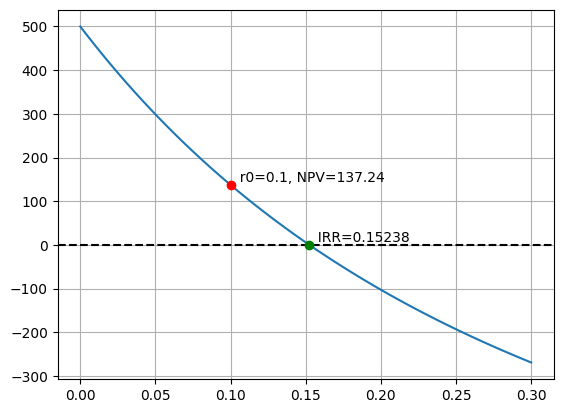

In [85]:
r = np.linspace(0, 0.3, 100)
y = [f(x) for x in r]

plt.plot(r, y)
plt.axhline(y=0, color='black', linestyle='--')  # горизонтальная линия y=0

y0 = f(r0)
plt.scatter([r0], [y0], color="red", zorder=3, label=f" r0={r0}")
plt.text(r0, y0, f"  r0={r0}, NPV={y0:.2f}", fontsize=10, verticalalignment='bottom')

plt.scatter([root], [0], color="green", zorder=3, label=f"Корень ≈ {root:.5f}")
plt.text(root, 0, f"  IRR={root:.5f}", fontsize=10, verticalalignment='bottom')
plt.grid(True)
plt.show()

Метод Ньютона (касательных) — это один из самых распространённых численных методов решения уравнений f(x) = 0. Его главная особенность — использование производной для быстрого поиска корня.

## Преимущества метода Ньютона

### 1. Высокая скорость сходимости (квадратичная)
Это главное преимущество. Вблизи корня количество верных знаков удваивается примерно на каждой итерации.
### 2. Не требует интервала с разными знаками
В отличие от методов половинного деления или хорд, Ньютону нужна только одна начальная точка x0.

### 3. Лёгкость обобщения на системы уравнений
Метод естественно распространяется на многомерный случай (решение систем нелинейных уравнений), где он сходится быстрее большинства альтернатив.

### 4. Простота реализации при наличии производной
Формула x_{n+1} = x_n - f(x_n)/f'(x_n) очень компактна и легко программируется.

## Недостатки метода Ньютона

### 1. Требует вычисления производной
 Если производную сложно или дорого считать аналитически метод теряет эффективность.

### 2. Чувствительность к начальному приближению
Метод сходится только если x0 достаточно близок к истинному корню. При неудачном выборе итерации могут:
- уйти в бесконечность;
- зациклиться (начать прыгать между двумя точками);
- сойтись к другому корню, не к тому, который искали.

### 3. Проблема с нулевой производной
Если в какой-то точке f'(x_n) = 0, происходит деление на ноль (вертикальная касательная не пересекает ось). В реальности возникает переполнение или коллапс алгоритма.

### 4. Плохая работа на кратных корнях
Если f(x) имеет кратный корень (т.е. f'(x*) = 0 одновременно с f(x*) = 0), скорость падает с квадратичной до линейной (как у простых методов).


## Задание 3

В экономике решают систему:
$$x = 2y - y^2$$
$$y = x - 0.5x^2$$
Найдите $(x, y)$ методом функциональной итерации с начальным приближением $(0.5, 0.5)$ и точностью $10^{-3}$.

*Объясните метод функциональной итерации для систем уравнений.*

**max 4 балла**

In [86]:
def fn_iteration(g, x0, tol, n_iterations=20):
    A = np.zeros((n_iterations + 1, len(x0)))
    A[0, :] = x0

    for i in range(n_iterations):
        A[i + 1, :] = g(A[i, :])

        if np.all(np.abs(A[i + 1, :] - A[i, :]) < tol):
            break

    return A[:i + 2]  # возвращаем только выполненные итерации

def g(x):
    res = np.zeros_like(x)
    res[0] = 2 * x[1] - x[1]**2
    res[1] = x[0] - 0.5 * x[0]**2
    return res

x0 = np.array([0.5, 0.5])
result = fn_iteration(g, x0, tol=1e-3)

print("Все итерации:", len(result))
print(result)
print("\nРешение:", result[-1])

Все итерации: 13
[[0.5        0.5       ]
 [0.75       0.375     ]
 [0.609375   0.46875   ]
 [0.71777344 0.42370605]
 [0.66788529 0.46017408]
 [0.70858798 0.44484991]
 [0.69180838 0.45753952]
 [0.70573662 0.45250896]
 [0.70025356 0.45670453]
 [0.70483004 0.45507604]
 [0.70305787 0.45643735]
 [0.70453964 0.45591269]
 [0.703969   0.45635159]]

Решение: [0.703969   0.45635159]


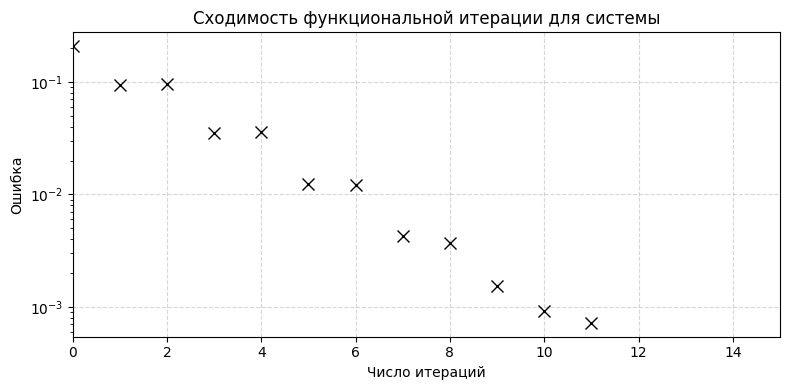

In [87]:
iters = range(len(result))
errors = np.linalg.norm(result - result[-1, :], 2, axis=1)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
ax.semilogy(iters, errors, 'kx', markersize=8, linewidth=1.5)
ax.set_xlabel("Число итераций")
ax.set_ylabel(r"Ошибка")
ax.set_xbound(0.0, 15.0)
ax.set_title("Сходимость функциональной итерации для системы")
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**ОТВЕТ** Метод функциональной итерации — это когда систему переписывают в виде
x=g(x), а потом многократно подставляют начальное приближение в правую часть:
$$x^{(k+1)} = g\!\left(x^{(k)}\right)$$

Если последовательность сходится, её предел и есть решение системы